<a href="https://colab.research.google.com/github/RAseng77/computer_vision_study/blob/main/%EC%BB%B4%ED%93%A8%ED%84%B0%EA%B8%B0%EB%B3%B8_%EA%B8%B0%EC%B4%88/%EC%8B%A4%EC%A0%9C%EC%98%81%EC%83%81vsAI%EC%83%9D%EC%84%B1%EC%98%81%EC%83%81_%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# numpy 1.x + imgaug 설치
!pip uninstall -y numpy imgaug
!pip install "numpy<2.0" "imgaug==0.4.0"

# 런타임 재시작 필요 (중요!)
import os, signal
os.kill(os.getpid(), signal.SIGKILL)

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.12.0.88
    Uninstalling opencv-python-4.12.0.88:
      Successfully uninstalled opencv-python-4.12.0.88
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have num

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/file/실제영상vsAI영상.zip1.zip" -d "/content/실제영상vsAI영상"

Archive:  /content/drive/MyDrive/file/실제영상vsAI영상.zip1.zip
  inflating: /content/실제영상vsAI영상/8/test/real/.DS_Store  
  inflating: /content/실제영상vsAI영상/8/test/styletransfer/.DS_Store  
  inflating: /content/실제영상vsAI영상/8/test/styletransfer/image1474.png  
  inflating: /content/실제영상vsAI영상/8/test/real/image1472.png  
  inflating: /content/실제영상vsAI영상/8/test/real/image1479.png  
  inflating: /content/실제영상vsAI영상/8/test/real/image1474.png  
  inflating: /content/실제영상vsAI영상/8/test/styletransfer/image1471.png  
  inflating: /content/실제영상vsAI영상/8/test/real/image1477.png  
  inflating: /content/실제영상vsAI영상/8/test/styletransfer/image1475.png  
  inflating: /content/실제영상vsAI영상/8/test/real/image1476.png  
  inflating: /content/실제영상vsAI영상/8/test/styletransfer/image1479.png  
  inflating: /content/실제영상vsAI영상/8/test/styletransfer/image1472.png  
  inflating: /content

In [3]:
!ls '/content/실제영상vsAI영상/8/test'

real  styletransfer


In [4]:
import os     # 파일/디렉토리 경로 처리
import glob   # 특정 패턴과 일치하는 파일 경로 검색
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch        # PyTorch 기본 패키지
import torch.nn as nn # 신경망 계층 (Linear, Conv2d 등)과 Loss 함수 모듈
import torch.optim as optim # 모델 최적화 알고리즘(Adam, SGD 등)
from torch.utils.data import DataLoader, Dataset
# Dataset: 사용자 정의 데이터셋 클래스 작성 시 상속
# DataLoader: 배치 단위 데이터 로딩, 셔플, 병렬 처리 지원

from torchvision.utils import make_grid
# 여러 이미지를 한 장의 grid로 합쳐서 시각화

from torchvision.datasets import ImageFolder
# 폴더 구조 기반 이미지 데이터셋 자동 생성

import torchvision.transforms as transforms
# 데이터 전처리/증강

import torchvision.models as models
# 사전 학습된 딥러닝 모델을 불러올 때 사용

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
print('Device: ',device)

Device:  cuda


In [7]:
# 이미지를 출력하는 함수
def display_images(image_paths, title, max_images=4):
  """
  지정된 경로의 이미지를 최대 4개까지 출력합니다.
  Args:
      image_paths (list): 이미지 파일 경로들의 리스트
      title (str): 각 이미지 위에 표시할 제목
      max_images (int): 한 번에 출력할 최대 이미지 개수 (기본값 4)
  """
  plt.figure(figsize=(12, 3)) # 출력될 전체 그림의 크기 (가로 12, 세로 3 인치)

  # enmerate를 사용해 index(i), image_path를 함께 가져옴
  for i, image_path in enumerate(image_paths[:max_images]):
    # 이미지 파일 읽기
    img = plt.imread(image_path)

    # 1행 max_images열 중 (i+1)번째 위치에 출력
    plt.subplot(1, max_images, i+1)

    # 이미지를 화면에 표시
    plt.imshow(img)

    plt.title(title)
    plt.axis('off')
  plt.show()


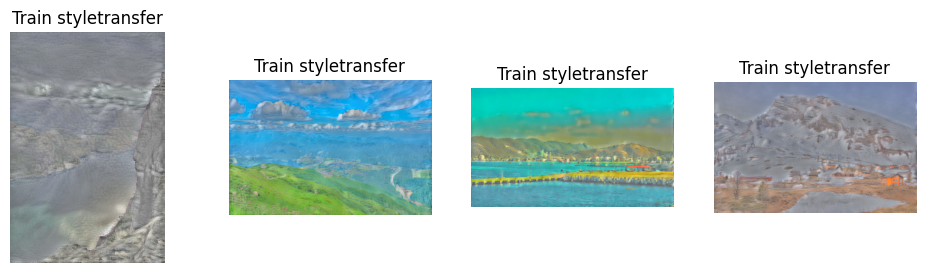

Train styletransfer 총 이미지 수: 374


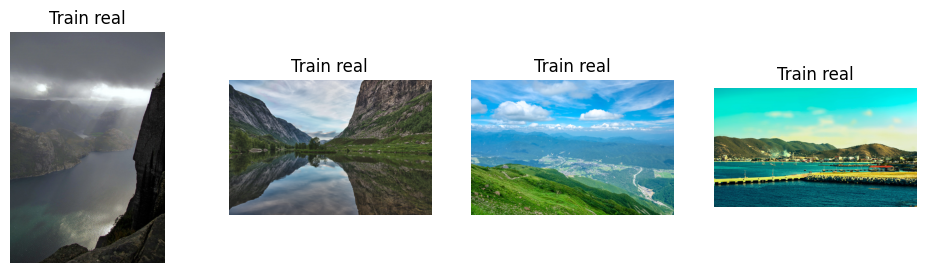

Train real 총 이미지 수: 539


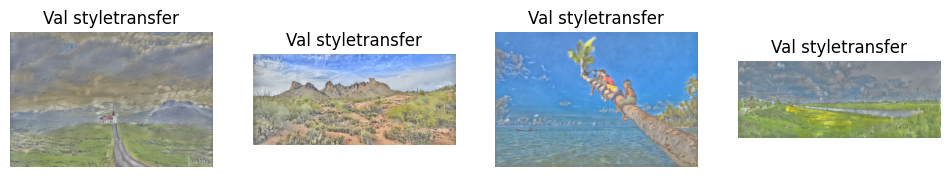

Val styletransfer 총 이미지 수: 109


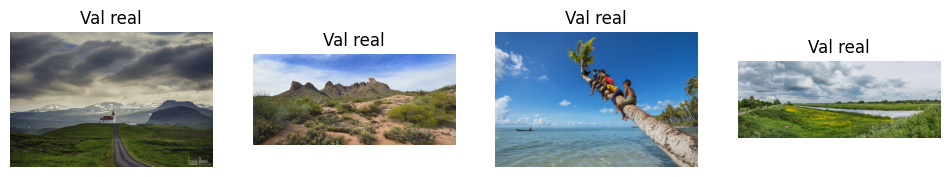

Val real 총 이미지 수: 109


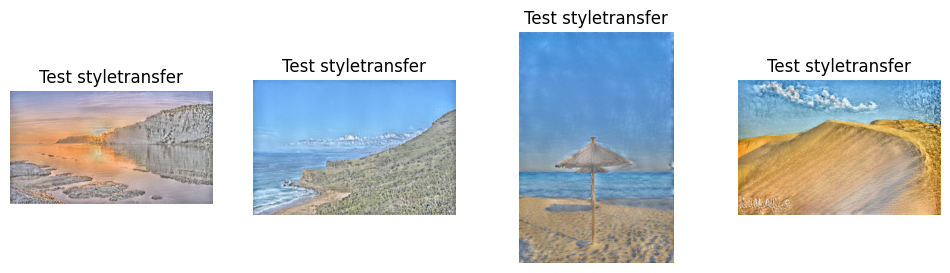

Test styletransfer 총 이미지 수: 32


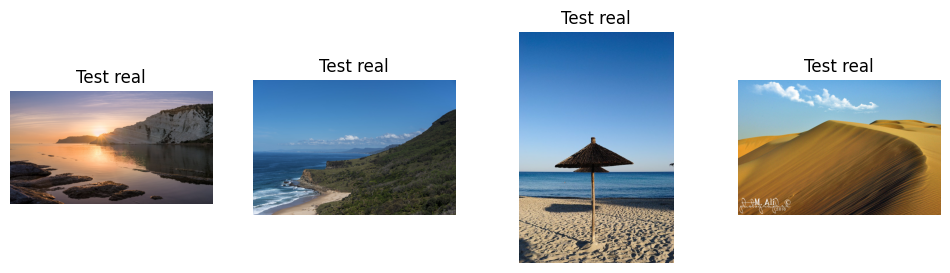

Test real 총 이미지 수: 32


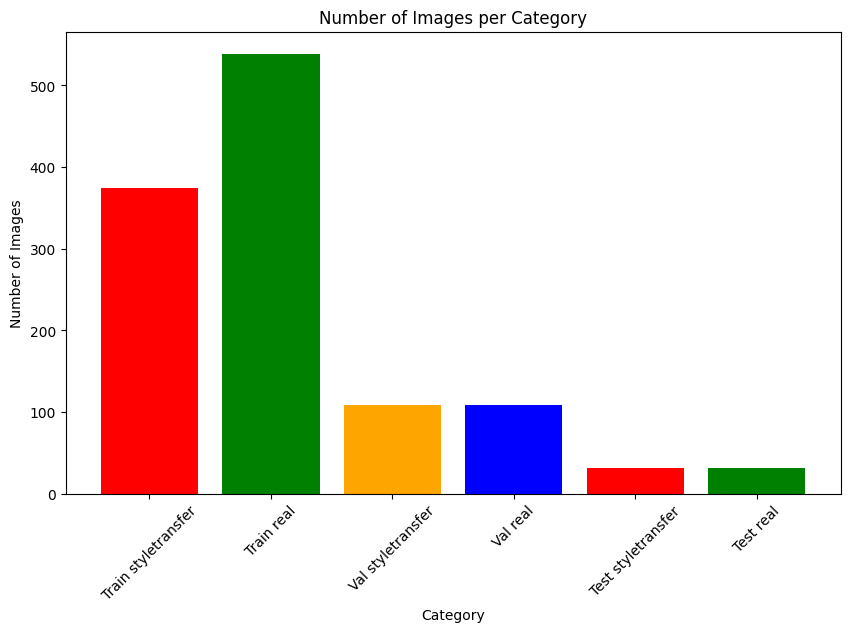

In [8]:
# 이미지와 바 그래프 출력
categories = ['Train styletransfer', 'Train real', 'Val styletransfer', 'Val real', 'Test styletransfer', 'Test real']

for category in categories:
  image_paths = glob.glob(f'/content/실제영상vsAI영상/8/{category.lower().replace(" ", "/")}/*')
  display_images(image_paths, category)
  print(f"{category} 총 이미지 수: {len(image_paths)}")


# 바 그래프 생성
plt.figure(figsize=(10, 6))
plt.bar(categories, [len(glob.glob(f'/content/실제영상vsAI영상/8/{category.lower().replace(" ", "/")}/*')) for category in categories], color=['red','green','orange','blue'])
plt.title('Number of Images per Category')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

In [9]:
from imgaug import augmenters as iaa
import imgaug as ia

# imgaug를 사용한 커스텀 데이터셋 정의
class ImgAugTransform:
  def __init__(self):
    # 여러 증강 기법을 순차적으로 적용하는 파이프라인
    self.aug = iaa.Sequential([
        iaa.Fliplr(0.5),
        iaa.Flipud(0.2),
        iaa.Affine(rotate=(-20, 20), mode='symmetric'),
        iaa.LinearContrast((0.75, 1.5)), # 이미지의 대비(contrast)를 0.75배 ~ 1.5배로 랜덤 조절
        iaa.ElasticTransformation(alpha=(0, 5.0), sigma=0.25),
        # 탄성 변형 (elastic deformation)
        # alpha -> 왜곡 강도 (0~5.0), sigma -> 스무딩 정도
    ])

  def __call__(self, img):
    # 입력 이미지를 numpy 배열로 변환 (PIL.Image -> np.array)
    img = np.array(img)
    # 정의된 증강 파이프라인을 적용하여 증강된 이미지 반환
    return self.aug.augment_image(img)

In [10]:
# 커스텀 데이터셋 클래스 정의
class CustomDataset(ImageFolder):
  def __init__(self, root, imgaug=None, transform=None, sample_per_class=None):
    # ImageFolder 초기화 (root 경로에 있는 폴더별 이미지를 자동으로 클래스 분류)
    super(CustomDataset, self).__init__(root, transform=transform)
    self.imgaug_transform = imgaug # imgaug 증강을 저장 (있으면 __getitem__ 에서 적용)

    # sample_per_class가 지정되면, 클래스별 샘플 개수를 줄여서 데이터셋 구성
    if sample_per_class is not None:
      self.samples = self._reduce_samples(sample_per_class)

  # 클래스별 샘플 수 제한 함수
  def _reduce_samples(self, sample_per_class):
    class_samples = {} # {class_id: [image_paths]} 형태로 저장

    # 전체 샘플(self.samples)을 클래스별로 분류
    for path, target in self.samples:
      if target not in class_samples:
        class_samples[target] = [path]
      else:
        class_samples[target].append(path)

    reduced_samples = []
    for target, paths in class_samples.items():
      # 해당 클래스의 이미지가 sample_per_class보다 많으면 랜덤 샘플링
      if len(paths) > sample_per_class:
        reduced_samples.extend([
            (path, target) for path in random.sample(paths, sample_per_class)
        ])
      # 아니라면, 원래 있던 샘플 그래도 사용
      else:
        reduced_samples.extend([
            (path, target) for path in paths
        ])

    return reduced_samples


  # 데이터셋에서 인덱스로 아이템을 가져오는 부분 (DataLoader에서 호출됨)
  def __getitem__(self, index):
    path, target = self.samples[index] # 이미지 경로와 라벨 가져오기
    img = self.loader(path)            # ImageFolder의 기본 loader로 불러오기

    # imgaug 증강 적용
    if self.imgaug_transform is not None:
      img = self.imgaug_transform(img) # numpy array 반환
      img = Image.fromarray(img)       # 다시 PIL Image로 변환

    # ToTensor 및 Normalize 적용
    if self.transform is not None:
      img = self.transform(img)

    return img, target

In [11]:
# PyTorch transforms에서 ToTensor 및 Normalize만 적용
from torchvision import transforms
pytorch_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [12]:
# 데이터셋 및 데이터 로더 초기화
train_dataset = CustomDataset('/content/실제영상vsAI영상/8/train', imgaug=ImgAugTransform(), transform=pytorch_transforms)
val_dataset = CustomDataset('/content/실제영상vsAI영상/8/val', imgaug=None, transform=pytorch_transforms, sample_per_class=20)

train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=False)

In [13]:
# DataLoader에서 샘플 이미지를 불러와 화면에 출력하는 함수
def imshow(img, labels, class_to_idx, size=(20, 20), mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)):
  # class_to_idx: {"cat": 0, "dog": 1} 형태
  # -> 이를 뒤집어서 {0: "cat", 1: "dog"} 형태로 만들어 클래스 이름을 쉽게 조회
  idx_to_class = {v:k for k, v in class_to_idx.items()}

  # PyTorch Tensor -> numpy array 변환
  # Tensor shape: (C, H, W) -> (H, W, C)로 변환
  img = img.numpy().transpose((1,2,0))

  # 정규화 해제 (역정규화하려면 numpy로 변환)
  mean = np.array(mean)
  std = np.array(std)
  img = img * std + mean
  img = np.clip(img, 0, 1) # 값 범위를 [0,1]로 제한 -> 시각화 시 색이 깨지지 않도록

  plt.figure(figsize=size)
  plt.imshow(img)
  plt.axis('off')

  # 이미지 위에 레이블 번호와 실제 클래스 이름 출력
  for i, label in enumerate(labels[:8]): # 배치 내 최대 8개까지만 출력
    class_name = idx_to_class[label.item()] # 정수 인덱스를 클래스명으로 변환

    # 텍스트 위치 계산
    # (i % 4) -> 4열 배치 (가로 위치 조정)
    # (i // 4) -> 2행 배치 (세로 위치 조정)
    x = (i % 4) * (img.shape[1] // 4) + 100
    y = (i // 4) * (img.shape[0] // 2) + 10

    # 이미지 위에 (클래스 인덱스, 클래스 이름) 표시
    plt.text(x, y, f'{label.item()}, {class_name}', color='white', fontsize=14)

  plt.show()


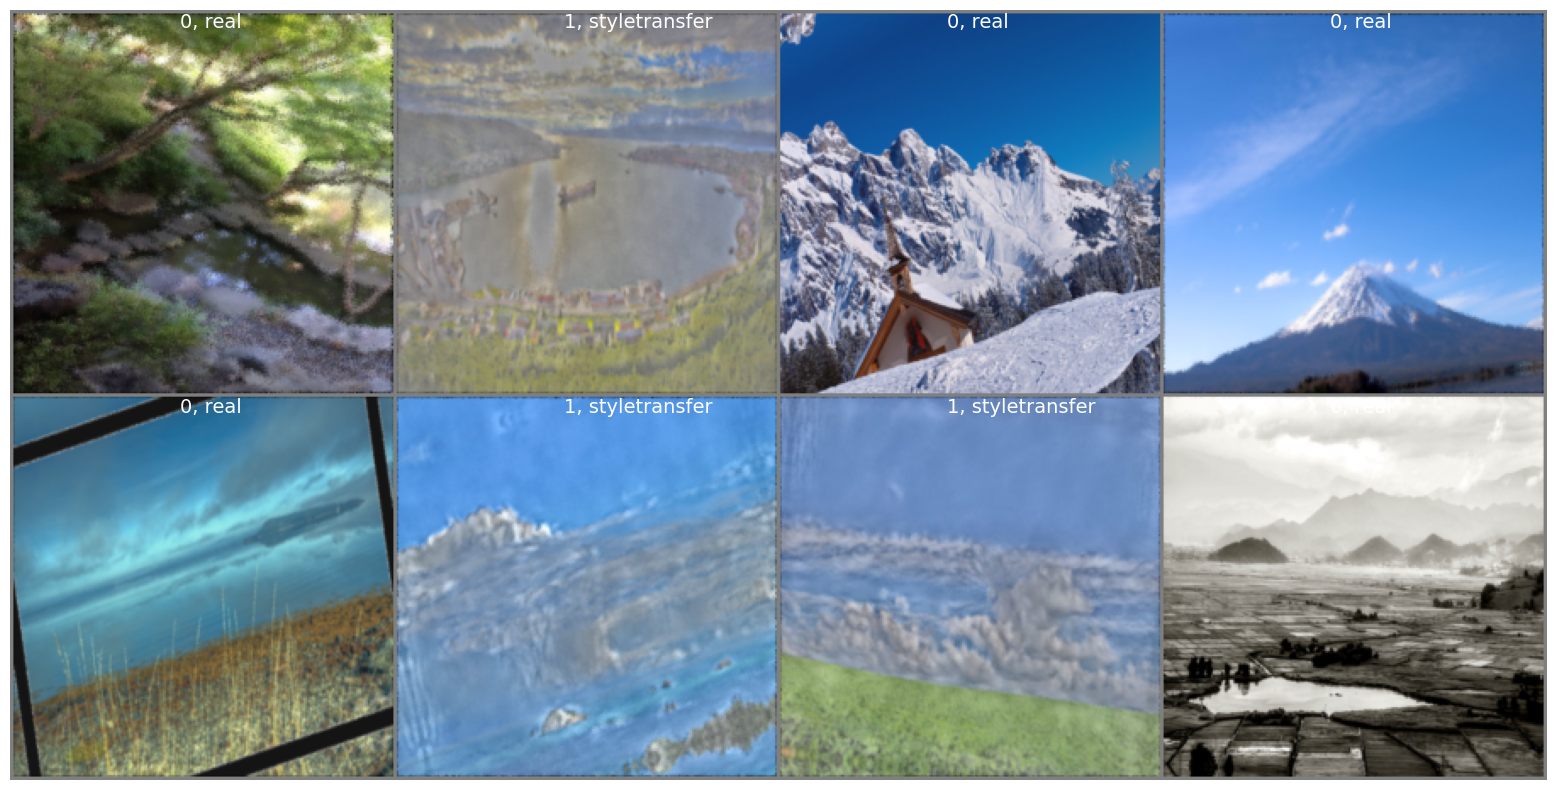

In [14]:
# DataLoader를 이용하여 배치 데이터 가져오기
dataiter = iter(train_loader)     # train_loader에서 iterator 생성
images, label = next(dataiter)    # 첫 번째 배치 꺼내오기

# class_to_idx 매핑 가져오기
# ImageFolder를 기반으로 만든 Dataset에는 class_to_idx 속성이 있음
# 예: {"cat": 0, "dog":1, "bird":2}
class_to_idx = train_loader.dataset.class_to_idx

# 이미지 그리드 생성 및 시각화, nrow를 조정하여 한 줄에 표시되는 이미지의 수 조정
imshow(make_grid(images[:8], nrow=4), label, class_to_idx, size=(20, 10))

In [15]:
# densenet 모델 로드 및 네트워크 구조 확인
densenet = models.densenet169(pretrained=True)

# 모델의 모든 파라미터를 고정
for param in densenet.parameters():
  param.requries_grad = False

print(densenet)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet169_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet169_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth


100%|██████████| 54.7M/54.7M [00:00<00:00, 99.1MB/s]


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [16]:
# classifier의 마지막 레이어를 Binary Classification Task에 맞게 교체하고, 이 레이어의 파라미터는 학습 가능하도록 설정
densenet.classifier = nn.Linear(1664, 1, bias=True)
densenet.classifier.requires_grad = True

densenet = densenet.to(device)

In [17]:
# 손실 함수
criterion = nn.BCEWithLogitsLoss()

In [18]:
def validate_model(net, val_loader, criterion):
    net.eval()  #  모델을 평가 모드로 전환 (Dropout, BatchNorm 비활성화)
    val_loss = 0.0   # 검증 손실 누적
    correct = 0      # 맞춘 샘플 개수
    total = 0        # 전체 샘플 개수

    #  검증 시에는 학습이 아니므로 gradient 계산 불필요 → 메모리/속도 최적화
    with torch.no_grad():
        for inputs, labels in val_loader:       # 배치 단위로 검증 데이터 가져오기
            inputs, labels = inputs.to(device), labels.to(device)

            # 이진 분류(Binary Classification) 가정
            # 레이블을 float으로 변환 후 (batch_size,) → (batch_size, 1)로 차원 맞추기
            labels = labels.float().unsqueeze(1)

            # 모델 추론 (outputs shape: (batch_size, 1))
            outputs = net(inputs)

            #  손실 계산 및 누적
            val_loss += criterion(outputs, labels).item()

            #  시그모이드로 확률 변환 후 0.5 기준으로 분류
            predicted = torch.sigmoid(outputs) > 0.5

            #  정확도 계산
            total += labels.size(0)                       # 전체 샘플 수
            correct += (predicted == labels).sum().item()  # 예측이 맞은 개수

    #  평균 손실
    val_loss /= len(val_loader)

    #  정확도 (%)
    val_accuracy = 100 * correct / total

    return val_loss, val_accuracy


In [19]:
def train_model(optimizer_name, net, train_loader, val_loader, criterion, num_epochs=10):
  # optimizer 설정
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(net.parameters(), lr=0.0003, momentum=0.9)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(net.parameters(), lr=0.0003, betas=(0.9, 0.999))
    elif optimizer_name == 'RAdam':
        optimizer = optim.RAdam(net.parameters(), lr=0.0003, betas=(0.9, 0.999))
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    # 학습/검증 손실과 검증 정확도를 저장할 리스트
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
      net.train()   # 학습 모드 (Dropout/BN 학습 동작)
      running_loss = 0.0

      # tqdm으로 학습 진행률 출력
      for i, (inputs, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch +1}/{num_epochs}")):
        # 배치를 디바이스로 이동
        inputs, labels = inputs.to(device), labels.to(device)

        # 이진분류 가정: (N,) -> (N,1) float 라벨로 변환 (BCEWithLogitsLoss 호환)
        labels = labels.float().unsqueeze(1)

        optimizer.zero_grad() # 누적된 gradient 초기화
        outputs = net(inputs) # 순전파 (logits)
        loss = criterion(outputs, labels) # 손실 계산
        loss.backward()       # 역전파 계산(gradient)
        optimizer.step()      # 가중치 갱신

        running_loss += loss.item() # 배치 손실 누적

      # 매 에포크마다 평균 학습 손실 계산
      train_loss = running_loss / len(train_loader)
      train_losses.append(train_loss)

      # 검증 손실 및 정확도 계산
      val_loss, val_accuracy = validate_model(net, val_loader, criterion)
      val_losses.append(val_loss)
      val_accuracies.append(val_accuracy)

      print(f'[{optimizer_name}] Epoch {epoch + 1}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, Validation Accuracy: {val_accuracy:.2f}%')

    return train_losses, val_losses, val_accuracies

In [20]:
train_losses_densenet, val_losses_densenet, val_accuracies_densenet = train_model('RAdam', densenet, train_loader, val_loader, criterion)

Epoch 1/10: 100%|██████████| 29/29 [01:56<00:00,  4.02s/it]


[RAdam] Epoch 1, Train Loss: 0.612905, Val Loss: 0.354967, Validation Accuracy: 90.00%


Epoch 2/10: 100%|██████████| 29/29 [01:58<00:00,  4.09s/it]


[RAdam] Epoch 2, Train Loss: 0.176224, Val Loss: 0.075925, Validation Accuracy: 100.00%


Epoch 3/10: 100%|██████████| 29/29 [02:00<00:00,  4.15s/it]


...

[RAdam] Epoch 8, Train Loss: 0.005833, Val Loss: 0.002769, Validation Accuracy: 100.00%


Epoch 9/10: 100%|██████████| 29/29 [01:45<00:00,  3.62s/it]


[RAdam] Epoch 9, Train Loss: 0.006174, Val Loss: 0.003563, Validation Accuracy: 100.00%


Epoch 10/10: 100%|██████████| 29/29 [01:46<00:00,  3.67s/it]


[RAdam] Epoch 10, Train Loss: 0.004061, Val Loss: 0.011565, Validation Accuracy: 100.00%


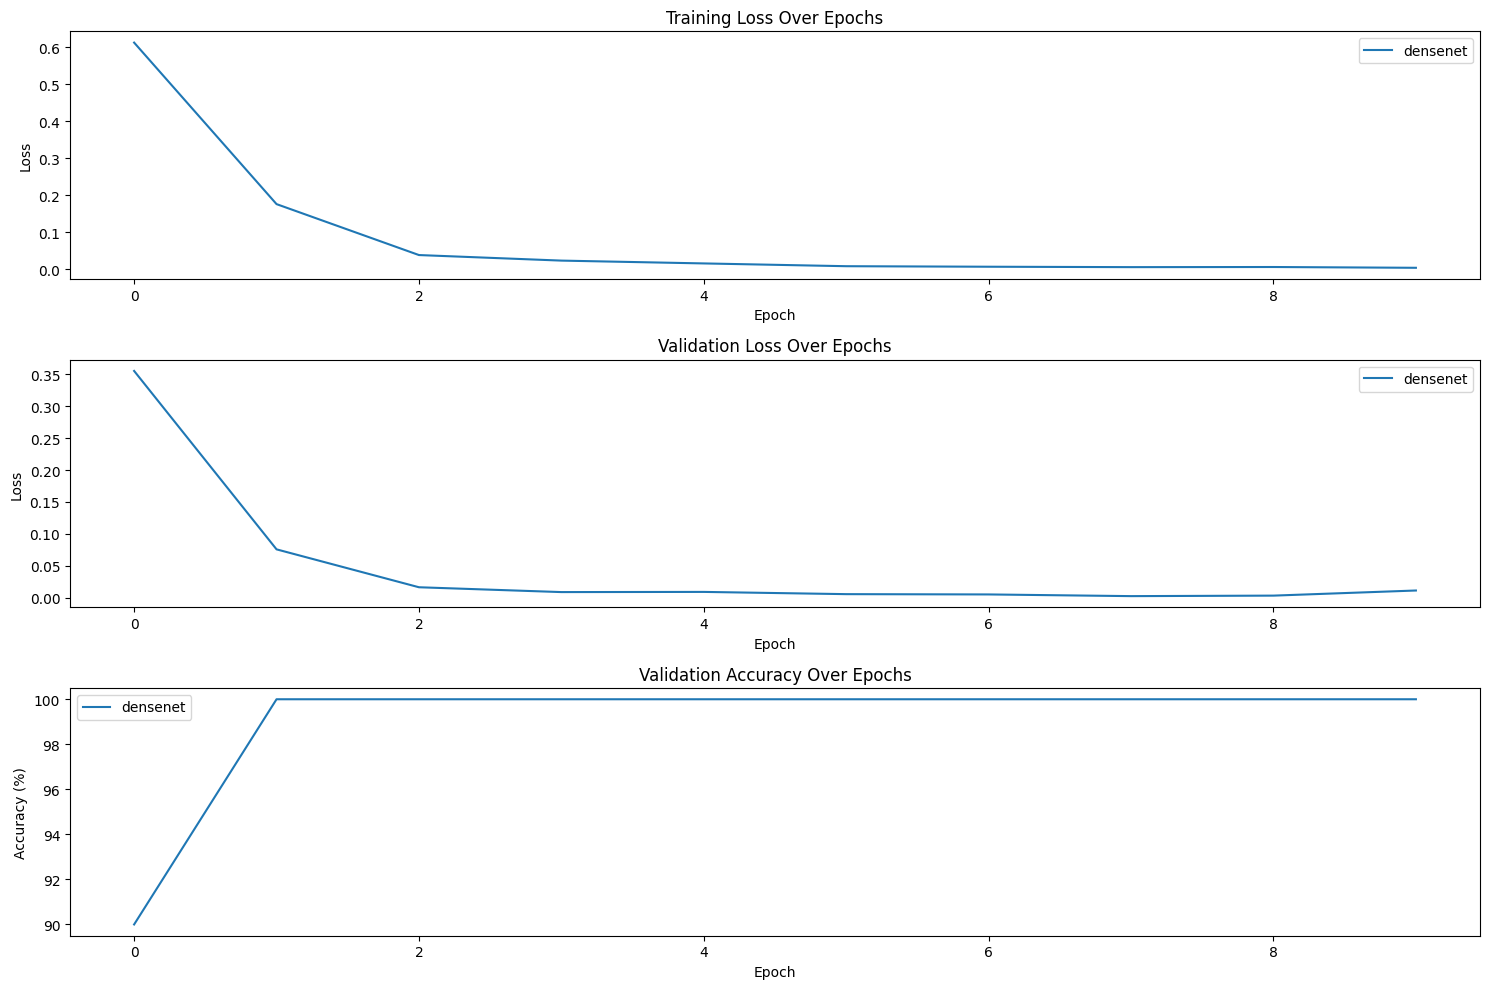

In [21]:
# 학습 손실과 검증 정확도 그래프 그리기
plt.figure(figsize=(15, 10))

# 학습 손실 그래프
plt.subplot(3, 1, 1)  # 3행 1열의 첫 번째 위치
plt.plot(train_losses_densenet, label='densenet')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# 검증 손실 그래프
plt.subplot(3, 1, 2)  # 3행 1열의 두 번째 위치
plt.plot(val_losses_densenet, label='densenet')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss Over Epochs')
plt.legend()

# 검증 정확도 그래프
plt.subplot(3, 1, 3)  # 3행 1열의 세 번째 위치
plt.plot(val_accuracies_densenet, label='densenet')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
# Image load 및 tensor로 변환
def load_and_transform_image(image_paths, transform):
  # 이미지 불러오기 (PIL 사용)
  image = Image.open(image_paths).convert('RGB')
  # transform 적용, 배치 차원 추가, device로 이동
  return transform(image).unsqueeze(0).to(device)

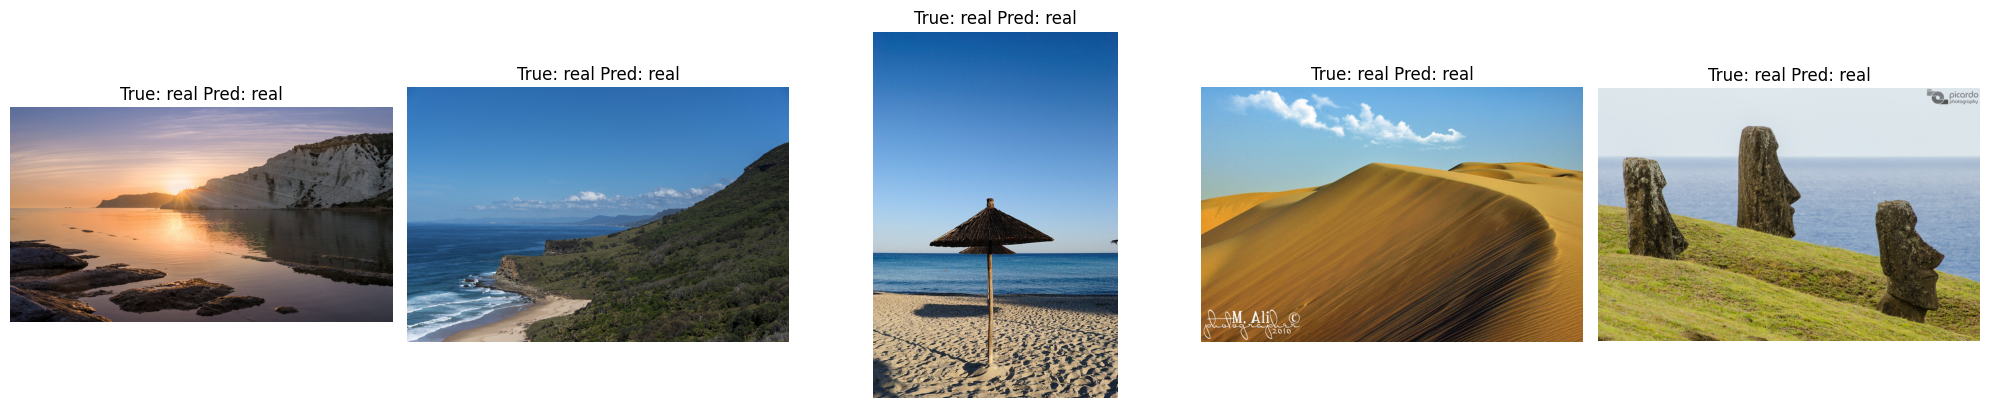

In [23]:
# 클래스별 폴더 경로
class_folders = {
    'styleTransfer': '/content/실제영상vsAI영상/8/test/styleTransfer',
    'real': '/content/실제영상vsAI영상/8/test/real'
}

plt.figure(figsize=(20, 8))
counter = 1

# 각 클래스별로 5장의 이미지 추론 및 시각화
for class_name, folder_path in class_folders.items():
  # 해당 클래스 플더에 있는 모든 이미지 경로
  image_paths = glob.glob(os.path.join(folder_path, '*'))
  selected_paths = image_paths[:5]

  for image_path in selected_paths:
    image = load_and_transform_image(image_path, pytorch_transforms)

    # 모델을 평가 모드로 설정 (Dropout, BatchNorm등 고정)
    densenet.eval()
    with torch.no_grad(): # 추론 시 gradient 계산 비활성화 (메모리/속도 절약)
      outputs = densenet(image) # 모델 출력 (logit 값)
      probs = torch.sigmoid(outputs).item() # 시그모이드로 확률(0~1) 변환 후 float값으로 꺼내기
      # 0.5 이상이면 styleTransfer, 아니면 real로 예측
      prediction = 'styleTransfer' if probs >= 0.5 else 'real'

    # 시각화
    plt.subplot(2, 5, counter)
    plt.imshow(Image.open(image_path)) # 원본 이미지 표시
    plt.title(f'True: {class_name} Pred: {prediction}')
    plt.axis('off')

    counter += 1

plt.tight_layout()
plt.show()